# Experimentation


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


print("cwd:", Path.cwd())
print("project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

cwd: /home/duvu/All/82_Master_Uliege/_Y2Q2/MLSD/ValoRe/notebooks
project root: /home/duvu/All/82_Master_Uliege/_Y2Q2/MLSD/ValoRe
src exists: True


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src.config import BQ_TABLE_FULL
from src.modeling.data_loading import load_dataframe
from src.modeling.preprocessing import clean_dataframe

In [3]:
sns.set_theme(style="whitegrid")

DATA_SOURCE = f"bq://{BQ_TABLE_FULL}"
TARGET_COL = "price"
SEED = 42
CV_FOLDS = 5

DATA_SOURCE

'bq://valore-mlsd-project.valore.housing_raw'

## Load and clean the data

In [4]:
df_raw = load_dataframe(DATA_SOURCE)
df = clean_dataframe(df_raw)

print("Raw shape:", df_raw.shape)
print("Processed shape:", df.shape)
df.head()

Raw shape: (21613, 21)
Processed shape: (21613, 21)


,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,...,yr_renovated,lat,long,sqm_living15,sqm_lot15,basement_ratio,year,month,day,dayofweek
0,142000.0,0,0.00,26.94187,1939.350125,1.0,0,0,1,1,...,0,47.5308,-121.888,150.50286,2122.83355,0.0,2014,9,26,4
1,262000.0,1,0.75,48.30956,1205.973843,1.0,0,0,5,3,...,0,47.2082,-121.995,124.49002,1136.482399,0.0,2015,2,25,2
2,75000.0,1,0.00,62.24501,4029.853431,1.0,0,0,3,3,...,0,47.2638,-121.906,107.76748,3983.866446,0.0,2015,2,17,1
3,280000.0,1,0.00,55.7418,2276.216403,1.0,0,0,2,3,...,0,47.5316,-121.749,91.97397,2094.869747,0.0,2014,11,4,1
4,145000.0,1,0.75,44.59344,905.80425,1.0,0,0,2,4,...,0,47.4982,-122.362,143.99965,921.969372,0.0,2014,8,25,0


In [5]:
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found")

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

numeric_cols = X.select_dtypes(include="number").columns.tolist()
X = X[numeric_cols]

print("Number of features kept:", len(numeric_cols))
numeric_cols

Number of features kept: 20


['bedrooms',
 'bathrooms',
 'sqm_living',
 'sqm_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'yr_built',
 'yr_renovated',
 'lat',
 'long',
 'sqm_living15',
 'sqm_lot15',
 'basement_ratio',
 'year',
 'month',
 'day',
 'dayofweek']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        )
    ],
    remainder="drop",
)

print(X_train.shape, X_test.shape)

(17290, 20) (4323, 20)


## Candidate models

In [7]:
model_zoo = {
    "dummy": {
        "model": DummyRegressor(),
        "param_grid": {"model__strategy": ["mean", "median"]},
    },
    "linear_regression": {
        "model": LinearRegression(),
        "param_grid": {},
    },
    "knn": {
        "model": KNeighborsRegressor(),
        "param_grid": {
            "model__n_neighbors": [5, 9, 15],
            "model__weights": ["uniform", "distance"],
        },
    },
    "random_forest": {
        "model": RandomForestRegressor(random_state=SEED, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 2],
        },
    },
    "xgboost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
        ),
        "param_grid": {
            "model__n_estimators": [100, 300],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [4, 6, 8],
        },
    },
}

list(model_zoo.keys())

['dummy', 'linear_regression', 'knn', 'random_forest', 'xgboost']

In [8]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def evaluate_predictions(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

## Model comparison and selection

In [9]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

results = []
fitted_models = {}
best_params_map = {}

for model_name, spec in model_zoo.items():
    pipe = Pipeline(
        [
            ("preprocess", preprocess),
            ("model", spec["model"]),
        ]
    )

    param_grid = spec["param_grid"]

    if param_grid:
        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            verbose=1,
            return_train_score=False,
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_rmse = -search.best_score_
    else:
        best_model = pipe.fit(X_train, y_train)
        best_params = {}
        best_cv_rmse = None

    pred_test = best_model.predict(X_test)
    metrics = evaluate_predictions(y_test, pred_test)

    results.append(
        {
            "model": model_name,
            "cv_rmse": best_cv_rmse,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_r2": metrics["r2"],
        }
    )
    fitted_models[model_name] = best_model
    best_params_map[model_name] = best_params

results_df = pd.DataFrame(results).sort_values("test_rmse")
results_df

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits


,model,cv_rmse,test_mae,test_rmse,test_r2
4,xgboost,126273.765134,61871.371565,108789.750679,0.904127
3,random_forest,131329.163523,68212.744501,120751.421732,0.881884
2,knn,182848.669311,96650.798538,172364.453977,0.759332
1,linear_regression,NaN,124767.645094,198791.338468,0.679877
0,dummy,370159.674692,227888.342628,351353.724006,-0.000027


In [10]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Selected model:", best_model_name)
print("Best params:", best_params_map[best_model_name])

Selected model: xgboost
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 300}


## Compare model performance visually

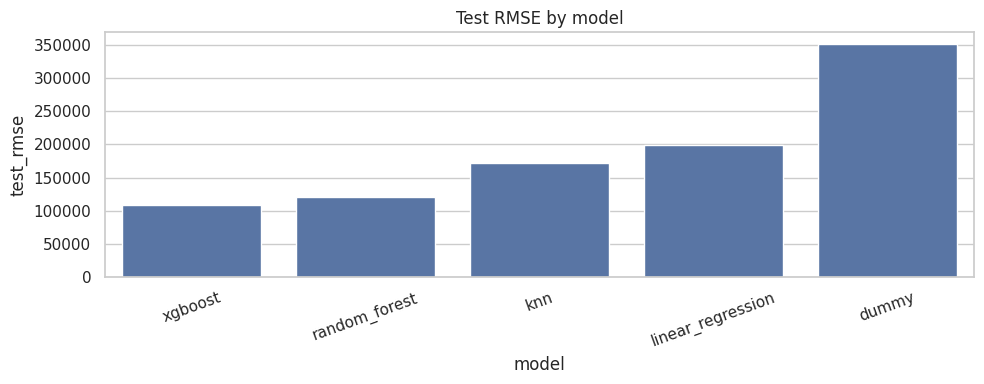

In [11]:
plot_df = results_df.copy()
plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="model", y="test_rmse")
plt.title("Test RMSE by model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Feature importance

,feature,importance
8,grade,0.439379
5,waterfront,0.191239
2,sqm_living,0.111339
11,lat,0.065468
6,view,0.044805
12,long,0.033487
9,yr_built,0.019867
13,sqm_living15,0.018131
10,yr_renovated,0.012648
1,bathrooms,0.008672


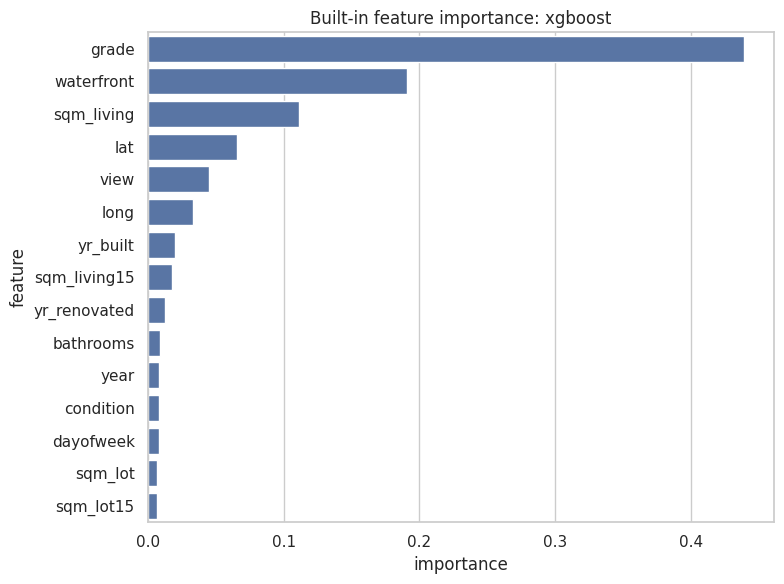

In [12]:
transformed_feature_names = numeric_cols
final_estimator = best_model.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": final_estimator.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(importance_df.head(15))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature")
    plt.title(f"Built-in feature importance: {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not expose built-in feature importance.")

,feature,importance_mean,importance_std
11,lat,0.422154,0.007598
2,sqm_living,0.242914,0.005005
12,long,0.190807,0.015227
8,grade,0.182119,0.007899
3,sqm_lot,0.041862,0.001595
13,sqm_living15,0.032736,0.002073
5,waterfront,0.031632,0.001994
9,yr_built,0.030898,0.002610
6,view,0.021268,0.000803
14,sqm_lot15,0.008449,0.000740


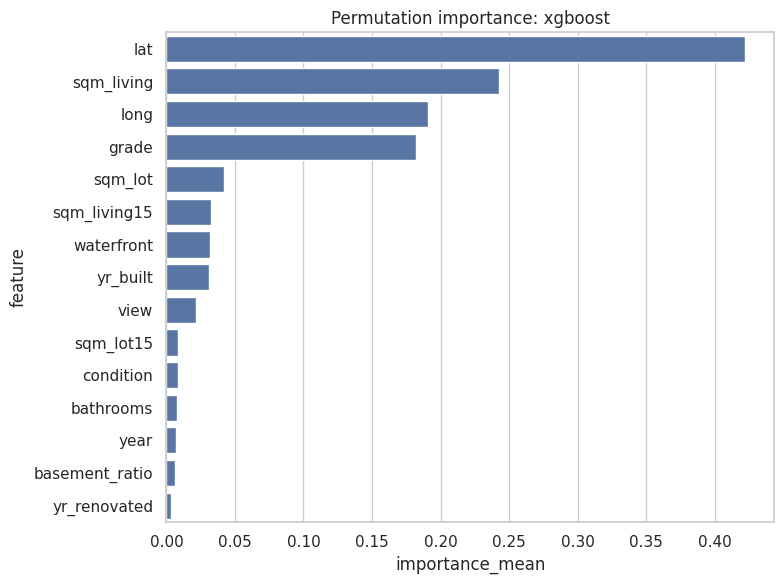

In [13]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = pd.DataFrame(
    {
        "feature": numeric_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(perm_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df.head(15), x="importance_mean", y="feature")
plt.title(f"Permutation importance: {best_model_name}")
plt.tight_layout()
plt.show()